# 02. Análise Exploratória de Dados (EDA)

## Contexto e Objetivos
A Análise Exploratória de Dados permite compreender a distribuição das variáveis, identificar inconsistências, detectar valores discrepantes (*outliers*) e mapear correlações com a variável alvo (`target`).

### Objetivos desta etapa:
1. Carregar o dataset armazenado na etapa de ingestão (`data/raw/heart_disease_raw.csv`).
2. Analisar a distribuição das variáveis numéricas contínuas.
3. Identificar a presença de *outliers* através de boxplots.
4. Avaliar a colinearidade entre variáveis via Matriz de Correlação de Pearson.
5. Investigar a relação bivariada entre features demográficas/fisiológicas e a presença de doença cardíaca.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Carregamento do dataset bruto
df = pd.read_csv("../data/raw/heart_disease_raw.csv")

# Inspeção das primeiras linhas para confirmação
df.head()

Matplotlib is building the font cache; this may take a moment.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1. Distribuição das Variáveis Numéricas

Análise da simetria e dispersão das variáveis numéricas contínuas: `age` (idade), `trestbps` (pressão arterial), `chol` (colesterol), `thalach` (frequência cardíaca máxima) e `oldpeak` (depressão do segmento ST).

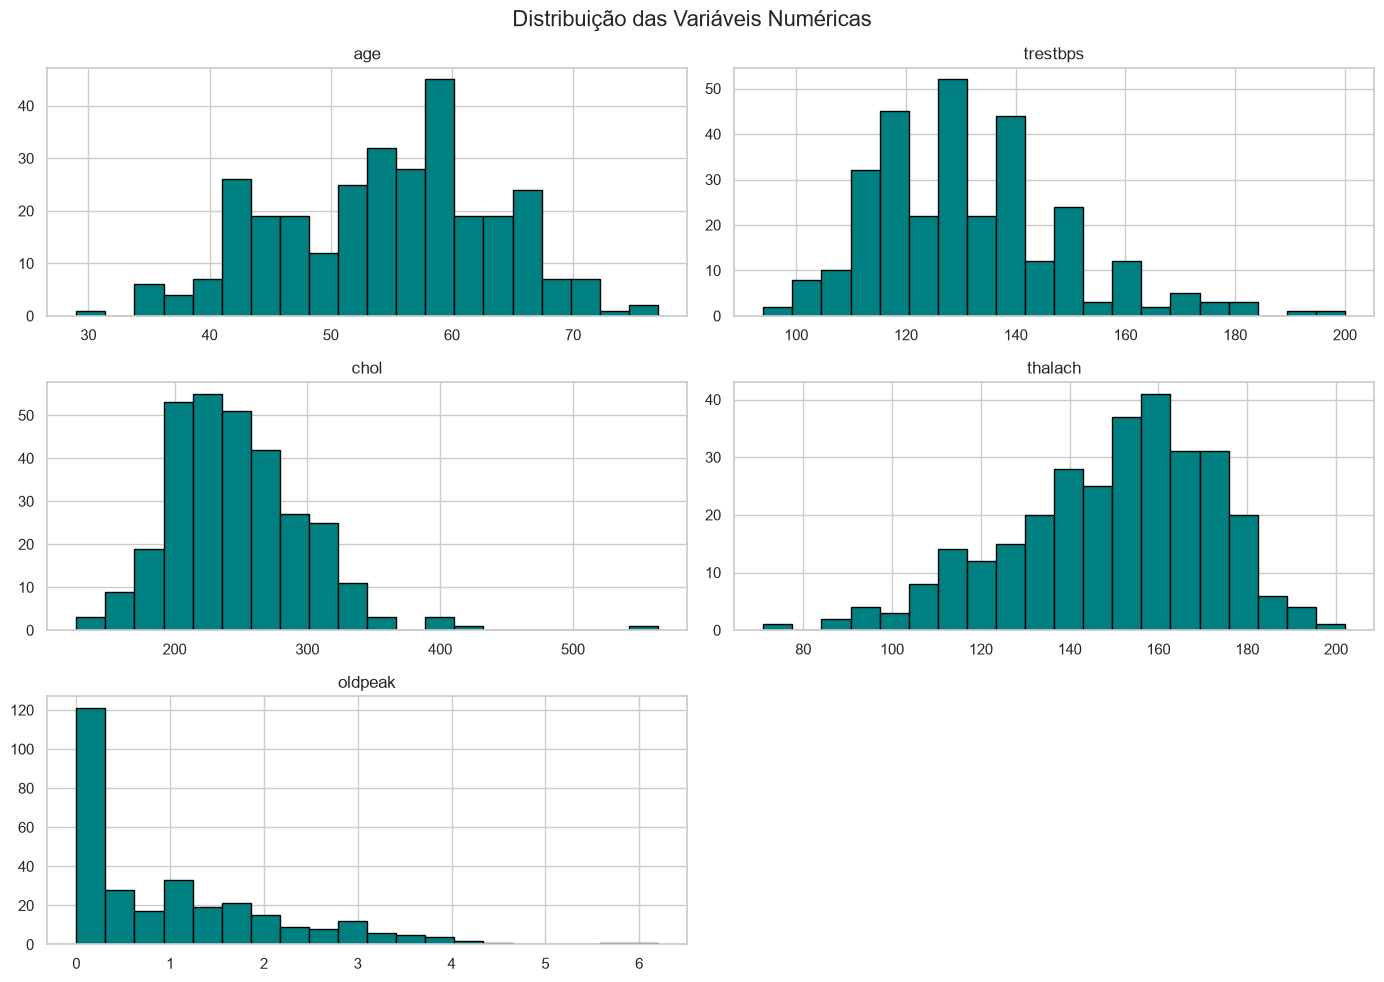

In [2]:
# Lista de features numéricas
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Histogramas das variáveis numéricas
df[num_features].hist(bins=20, figsize=(14, 10), color='teal', edgecolor='black')
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

## 2. Detecção de Outliers

Utilização de gráficos do tipo Boxplot para identificar observações fora do intervalo interquartil (IQR). *Outliers* em variáveis de saúde podem representar dados errôneos ou casos clínicos extremos que exigem atenção no pré-processamento.

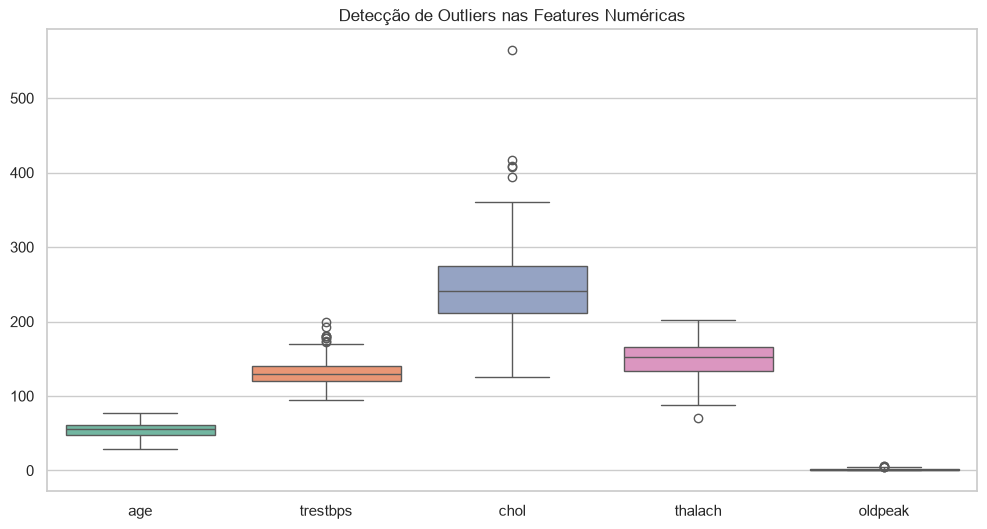

In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_features], palette="Set2")
plt.title("Detecção de Outliers nas Features Numéricas")
plt.show()

## 3. Matriz de Correlação de Pearson

Mapeamento de relações lineares entre todas as variáveis do conjunto de dados. Esta análise ajuda a identificar:
- Multicolinearidade entre preditores.
- Variáveis com maior força de associação com a variável alvo (`target`).

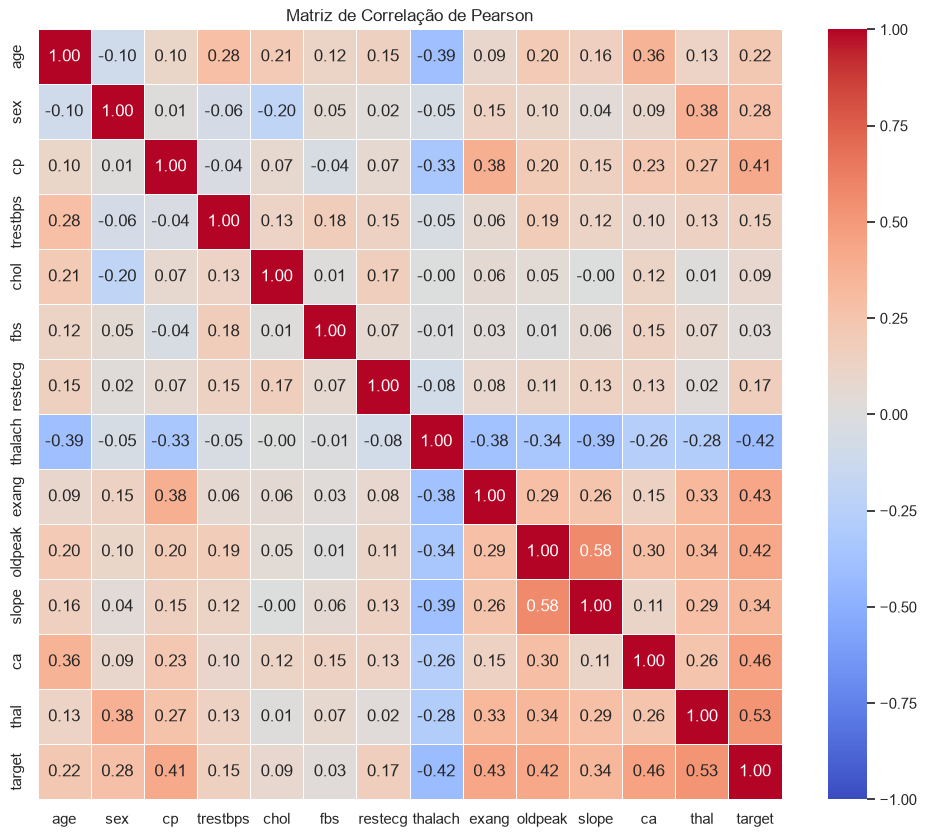

In [4]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)

plt.title("Matriz de Correlação de Pearson")
plt.show()

## 4. Análise Bivariada: Idade vs. Frequência Cardíaca Máxima

Investigação conjunta de `age` e `thalach`, segmentadas pelo diagnóstico (`target`). Essa visualização busca testar a hipótese de que a redução da frequência cardíaca máxima associada ao avanço da idade correlaciona-se com maior incidência da doença.

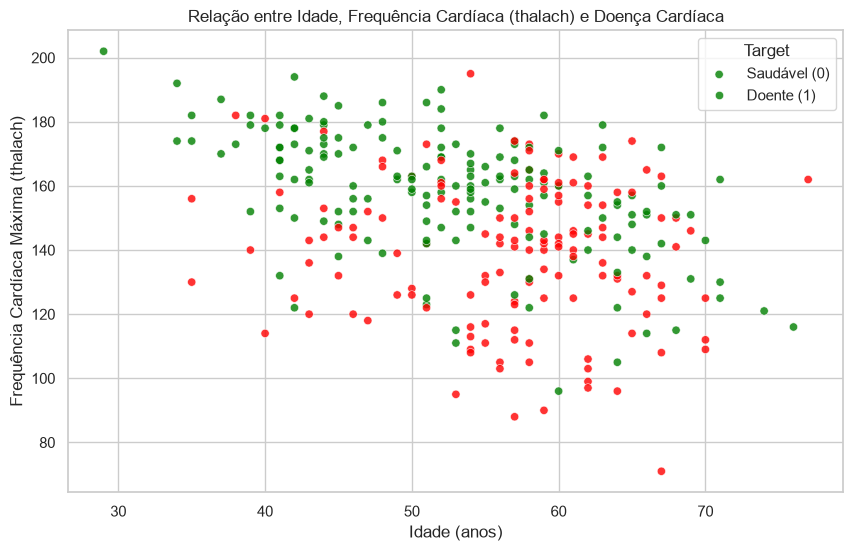

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='age', 
    y='thalach', 
    hue='target', 
    palette={0: "green", 1: "red"}, 
    alpha=0.8
)

plt.title("Relação entre Idade, Frequência Cardíaca (thalach) e Doença Cardíaca")
plt.xlabel("Idade (anos)")
plt.ylabel("Frequência Cardíaca Máxima (thalach)")
plt.legend(title="Target", labels=["Saudável (0)", "Doente (1)"])
plt.show()

## 5. Principais Insights da Análise Exploratória

1. **Assimetria e Distorções:** A variável `oldpeak` apresenta assimetria à direita marcante, com a maioria dos valores concentrados em zero.
2. **Presença de Outliers:** Identificados valores elevados pontuais em `chol` (colesterol) acima de 400 mg/dl e em `trestbps` acima de 170 mm Hg.
3. **Correlações Relevantes:**
   - `cp` (tipo de dor no peito), `thalach` e `slope` apresentam forte associação com a variável alvo.
   - `thalach` (frequência cardíaca máxima) demonstra correlação negativa com `target`, indicando que pacientes doentes tendem a atingir frequências cardíacas menores no teste de esforço.